In [1]:
import warnings
import sys

if not sys.warnoptions:
    warnings.simplefilter("ignore")
import os
import glob
import numpy as np

from nilearn import datasets, surface
from nilearn import plotting
from nilearn.input_data import NiftiMasker, NiftiLabelsMasker
from nilearn.glm import threshold_stats_img
from nilearn.glm.first_level import FirstLevelModel, make_first_level_design_matrix
from nilearn.glm.second_level import SecondLevelModel, make_second_level_design_matrix 
from nilearn.surface import SurfaceImage
import nibabel as nib

from brainiak import image, io
from brainiak.isc import isc, isfc, permutation_isc
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="white", context="notebook", font_scale=1, rc={"lines.linewidth": 2})

In [3]:
bids_dir = "/home/NEU480/datasets/narratives/"
fmriprep_dir = bids_dir + "derivatives/fmriprep/"
cleaned_dir = bids_dir + "derivatives/afni-nosmooth/"
stimuli_dir = bids_dir + "stimuli/"
transcript_dir =  "/home/vm5631/stimuli/transcripts_with_events/"
dir_nilearn = "/home/NEU480/datasets/nilearn_data"
code_dir = bids_dir + "code/"
net_id = os.environ['USER']
scratch_folder = f"/scratch/network/{net_id}/"
thesis_folder = scratch_folder + "thesis/"
z_map_folder = thesis_folder + "z_maps/"

In [4]:
# Load the fsaverage6 mesh once (needed to construct SurfaceImage)
fsaverage6 = datasets.fetch_surf_fsaverage('fsaverage6', data_dir=thesis_folder)
fsaverage6_mesh = surface.PolyMesh(
    left=fsaverage6['pial_left'],
    right=fsaverage6['pial_right']
)

[fetch_surf_fsaverage] Dataset found in /scratch/network/vm5631/thesis/fsaverage6

In [5]:
import json
import pandas as pd


def json_to_events(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    events_list = []
    for event in data['annotations']['events']:
        events_list.append({
            'onset': event['start'],
            'duration': event['end'] - event['start'],
            'trial_type': event['label']  # e.g., 'punchline' or 'audience_laughter'
        })
    
    return pd.DataFrame(events_list)

In [6]:
def fetch_shared_punchlines(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    events_list = []
    for event in data['annotations']['events']:
        if 'shared_punchline_id' in event:
            events_list.append({
                'onset': event['start'],
                'duration': event['end'] - event['start'],
                'trial_type': event['label']  # e.g., 'punchline' or 'audience_laughter'
            })
    
    return pd.DataFrame(events_list)

In [7]:
events_live = json_to_events('stimuli/transcripts_with_events/pieman_audio.json')
events_pni = json_to_events('stimuli/transcripts_with_events/piemanpni_audio.json')
events_pni['onset'] = events_pni['onset'] + 12 # account for extra silence in the beginning

In [8]:
shared_punchlines_live = fetch_shared_punchlines('stimuli/transcripts_with_events/pieman_audio.json')
shared_punchlines_pni = fetch_shared_punchlines('stimuli/transcripts_with_events/piemanpni_audio.json')
shared_punchlines_pni['onset'] = shared_punchlines_pni['onset'] + 12

In [9]:
tr = 1.5
n_scans_live = 300
n_scans_pni = 294
trim_front_live = 10
trim_back_live = 8
trim_front_pni = 14
trim_back_pni = 13
exclude_subjects_live = [1, 13, 14, 21, 22, 38, 56, 68, 69]
subs_live = [(i + 1) for i in range(16, 82)]
exclude_subjects_pni = [266, 268, 269, 270, 271, 280]
subs_pni = [(i + 1) for i in range(264, 315)]
frame_times_live = np.arange(n_scans_live) * tr
frame_times_pni = np.arange(n_scans_pni) * tr

In [10]:
def remove_subjects(sub_list, exclude_list):
    cleaned_list = sub_list
    for sub in exclude_list:
        if sub in sub_list:
            cleaned_list.remove(sub) 
    return cleaned_list

In [11]:
subs_live = remove_subjects(subs_live, exclude_subjects_live)

In [12]:
subs_pni = remove_subjects(subs_pni, exclude_subjects_pni)
subs_pni.append(127)

In [13]:
import random

def get_random_items(data_list, count):
    # random.sample raises an error if count > len(data_list)
    if count > len(data_list):
        return "Count is larger than the list size!"
    
    return random.sample(data_list, count)

In [14]:
live_random = get_random_items(subs_live, 45)
live_random

[75,
 37,
 78,
 35,
 19,
 65,
 49,
 73,
 79,
 76,
 63,
 40,
 59,
 52,
 29,
 77,
 45,
 71,
 27,
 24,
 30,
 42,
 74,
 41,
 72,
 54,
 20,
 55,
 66,
 81,
 32,
 82,
 17,
 46,
 58,
 34,
 70,
 62,
 43,
 48,
 23,
 44,
 33,
 64,
 25]

In [15]:
pni_random = get_random_items(subs_pni, 45)
pni_random

[295,
 265,
 310,
 298,
 279,
 301,
 281,
 283,
 297,
 307,
 284,
 291,
 304,
 312,
 288,
 286,
 309,
 282,
 127,
 314,
 315,
 293,
 292,
 267,
 285,
 289,
 303,
 313,
 273,
 287,
 290,
 274,
 299,
 300,
 296,
 275,
 306,
 311,
 277,
 272,
 308,
 305,
 276,
 294,
 302]

In [16]:
spp_modified = shared_punchlines_pni
spp_modified['onset'] = shared_punchlines_pni['onset'] + 1

spl_modified = shared_punchlines_live
spl_modified['onset'] = shared_punchlines_live['onset'] + 1

In [17]:
def generate_z_maps_gifti(events, subs, task):
    """
    Run first-level GLM on GIfTI surface data.
    Both hemispheres are combined into a single SurfaceImage per subject.

    Returns a list of SurfaceImage z-maps, one per subject.
    """
    z_maps = []

    for sub in subs:
        gifti_imgs = {}
        for hemi, side in [('L', 'left'), ('R', 'right')]:
            file_name = (
                f"sub-{sub:03d}_task-{task}_space-fsaverage6"
                f"_hemi-{hemi}_desc-clean.func.gii"
            )
            file_dir = f"{cleaned_dir}sub-{sub:03d}/func/"
            gifti_imgs[side] = file_dir + file_name  # pass path, not loaded image

        surf_img = SurfaceImage(
            mesh=fsaverage6_mesh,
            data=gifti_imgs  # {'left': path_L, 'right': path_R}
        )

        print(f"sub-{sub:03d}: {surf_img.shape}")

        glm = FirstLevelModel(
            t_r=1.5,
            signal_scaling=False,
            noise_model='ar1',
            standardize=False
        )

        glm.fit(surf_img, events=events)
        z_maps.append(glm.compute_contrast('punchline', output_type='z_score'))

    return z_maps

In [18]:
z_maps_pni = generate_z_maps_gifti(shared_punchlines_pni, pni_random[:3], 'piemanpni')

sub-295: (81924, 294)
sub-265: (81924, 294)
sub-310: (81924, 294)


In [19]:
z_maps_live = generate_z_maps_gifti(shared_punchlines_live, live_random[:3], 'pieman')

sub-075: (81924, 300)
sub-037: (81924, 300)
sub-078: (81924, 300)


In [20]:
def plot_z_map_surface(z_map, title="Z-map", threshold=3.1):
    """Plot a SurfaceImage z-map on both hemispheres, lateral and medial views."""
    plotting.plot_surf_stat_map(
        surf_mesh=fsaverage6_mesh,
        stat_map=z_map,
        hemi='left',
        view='lateral',
        title=f"{title} - Left (lateral)",
        threshold=threshold,
        colorbar=True,
        cmap='cold_hot'
    )
    plotting.plot_surf_stat_map(
        surf_mesh=fsaverage6_mesh,
        stat_map=z_map,
        hemi='right',
        view='lateral',
        title=f"{title} - Right (lateral)",
        threshold=threshold,
        colorbar=True,
        cmap='cold_hot'
    )
    plotting.show()

In [21]:
def plot_z_map_surface_all_views(z_map, title="", threshold=3.1):
    """Plot lateral and medial views for both hemispheres in one figure."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), subplot_kw={'projection': '3d'})
    
    views = [('left', 'lateral'), ('left', 'medial'),
             ('right', 'lateral'), ('right', 'medial')]
    
    for ax, (hemi, view) in zip(axes.flat, views):
        plotting.plot_surf_stat_map(
            surf_mesh=fsaverage6_mesh,
            stat_map=z_map,
            hemi=hemi,
            view=view,
            threshold=threshold,
            colorbar=True,
            cmap='cold_hot',
            axes=ax
        )
    
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plotting.show()

In [22]:
# pick the pial surface you want to display
surf_mesh_left = fsaverage6.pial_left
surf_mesh_right = fsaverage6.pial_right

# sulcal maps for background shading
bg_map_left = fsaverage6.sulc_left
bg_map_right = fsaverage6.sulc_right


In [26]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D

def plot_z_map_surface_all_views(
    z_map,
    title="",
    threshold=1.3,
    vmax=None,
    darkness=0.6,
    cmap='cold_hot',
):
    """
    Plot lateral and medial views for both hemispheres in one figure
    with one colorbar per row, divider lines, and sulcal shading.

    Parameters
    ----------
    z_map : str or surface texture
        Surface statistical map.
    title : str
        Figure title.
    threshold : float
        Statistical threshold for display.
    vmax : float or None
        Max absolute value for symmetric color scaling.
        If None, estimated from the data.
    darkness : float
        Darkness of sulcal shading background.
    cmap : matplotlib colormap
        Colormap to use.
    """

    # Project volumetric map to each hemisphere if needed.
    # If z_map is already a surface texture, you can replace this part
    # with your own left/right textures.
    stat_map_left = z_map.data.parts["left"]
    stat_map_right = z_map.data.parts["right"]

    # symmetric color limits
    if vmax is None:
        vmax = np.nanmax(
            np.abs(np.concatenate([stat_map_left.ravel(), stat_map_right.ravel()]))
        )
        # avoid accidental tiny vmax
        vmax = max(vmax, threshold)

    fig = plt.figure(figsize=(13, 9))
    gs = fig.add_gridspec(
        2, 3,
        width_ratios=[1, 1, 0.06],
        wspace=0.02,
        hspace=0.10
    )

    # 2x2 brain panels
    ax00 = fig.add_subplot(gs[0, 0], projection="3d")
    ax01 = fig.add_subplot(gs[0, 1], projection="3d")
    ax10 = fig.add_subplot(gs[1, 0], projection="3d")
    ax11 = fig.add_subplot(gs[1, 1], projection="3d")

    # one colorbar axis per row, at far right
    cax_top = fig.add_subplot(gs[0, 2])
    cax_bottom = fig.add_subplot(gs[1, 2])

    panels = [
        (ax00, stat_map_left,  surf_mesh_left,  bg_map_left,  "left",  "lateral"),
        (ax01, stat_map_right, surf_mesh_right, bg_map_right, "right", "lateral"),
        (ax10, stat_map_left,  surf_mesh_left,  bg_map_left,  "left",  "medial"),
        (ax11, stat_map_right, surf_mesh_right, bg_map_right, "right", "medial"),
    ]

    for ax, stat_map, surf_mesh, bg_map, hemi, view in panels:
        plotting.plot_surf_stat_map(
            surf_mesh=surf_mesh,
            stat_map=stat_map,
            hemi=hemi,
            view=view,
            bg_map=bg_map,          # adds sulcal shading
            # darkness=darkness,      # controls how strong the shading looks
            threshold=threshold,
            colorbar=False,         # IMPORTANT: no per-panel colorbars
            cmap=cmap,
            symmetric_cbar=True,
            vmax=vmax,
            axes=ax,
        )

    # Build one colorbar per row
    norm = Normalize(vmin=-vmax, vmax=vmax)
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cb_top = fig.colorbar(sm, cax=cax_top)
    cb_bottom = fig.colorbar(sm, cax=cax_bottom)

    for cb in (cb_top, cb_bottom):
        cb.set_label("z-score", rotation=270, labelpad=12)

    # Optional: divider lines between columns and rows
    # Draw after layout so positions are stable
    fig.canvas.draw()

    # vertical divider between the two brain columns
    x_mid = (ax00.get_position().x1 + ax01.get_position().x0) / 2
    y_bottom = min(ax10.get_position().y0, ax11.get_position().y0)
    y_top = max(ax00.get_position().y1, ax01.get_position().y1)

    fig.add_artist(Line2D(
        [x_mid, x_mid], [y_bottom, y_top],
        transform=fig.transFigure,
        color="lightgray",
        linewidth=1.2
    ))

    # horizontal divider between the two rows
    y_mid = (ax10.get_position().y1 + ax00.get_position().y0) / 2
    x_left = min(ax00.get_position().x0, ax10.get_position().x0)
    x_right = max(cax_top.get_position().x1, cax_bottom.get_position().x1)

    fig.add_artist(Line2D(
        [x_left, x_right], [y_mid, y_mid],
        transform=fig.transFigure,
        color="lightgray",
        linewidth=1.2
    ))

    # fig.suptitle(title, fontsize=14, y=0.98)
    plt.savefig(title + ".png")
    plt.show()

In [23]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt

def interactive_surface_plot(stat_map, threshold=1.3, title="", cmap='cold_hot'):
    """
    Interactive surface viewer with hemisphere/view dropdowns.
    Renders inline in Jupyter — change dropdowns to update without rerunning.
    """
    hemi_dropdown = widgets.Dropdown(
        options=[('Left', 'left'), ('Right', 'right')],
        value='left',
        description='Hemisphere:',
        layout=widgets.Layout(width='200px')
    )
    view_dropdown = widgets.Dropdown(
        options=['lateral', 'medial', 'dorsal', 'ventral', 'anterior', 'posterior'],
        value='lateral',
        description='View:',
        layout=widgets.Layout(width='200px')
    )
    out = widgets.Output()

    def update(change=None):
        with out:
            out.clear_output(wait=True)
            fig, ax = plt.subplots(
                figsize=(8, 6),
                subplot_kw={'projection': '3d'}
            )
            plotting.plot_surf_stat_map(
                surf_mesh=fsaverage6_mesh,
                stat_map=stat_map,
                hemi=hemi_dropdown.value,
                view=view_dropdown.value,
                threshold=threshold,
                colorbar=True,
                cmap=cmap,
                # title=f"{title} | {hemi_dropdown.value} {view_dropdown.value}",
                axes=ax
            )
            plt.tight_layout()
            plt.show()

    hemi_dropdown.observe(update, names='value')
    view_dropdown.observe(update, names='value')

    controls = widgets.HBox([hemi_dropdown, view_dropdown])
    display(widgets.VBox([controls, out]))
    update()  # render immediately on call

In [24]:
import ipywidgets as widgets
from IPython.display import display

def interactive_view_surf(stat_map, threshold=1.3, title=""):
    hemi_dropdown = widgets.Dropdown(
        options=[('Left', 'left'), ('Right', 'right')],
        value='left',
        description='Hemisphere:',
    )
    out = widgets.Output()

    def update(change=None):
        with out:
            out.clear_output(wait=True)
            view = plotting.view_surf(
                surf_mesh=fsaverage6_mesh.parts[hemi_dropdown.value],
                surf_map=stat_map.data.parts[hemi_dropdown.value],
                threshold=threshold,
            )
            display(view)

    hemi_dropdown.observe(update, names='value')
    display(widgets.VBox([hemi_dropdown, out]))
    update()

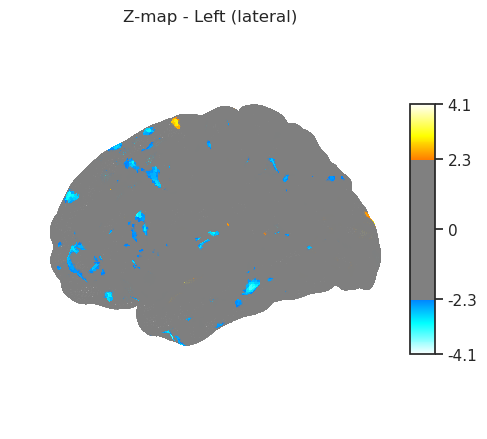

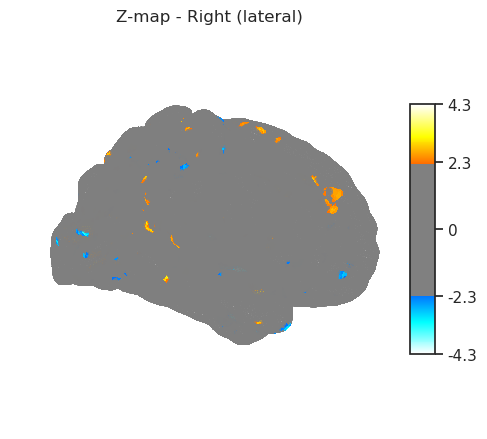

In [30]:
plot_z_map_surface(z_maps_pni[1], threshold=2.3)

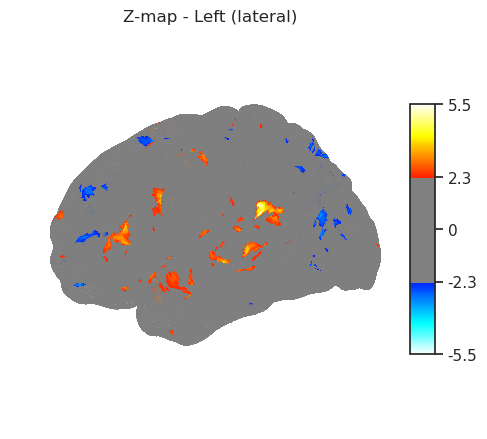

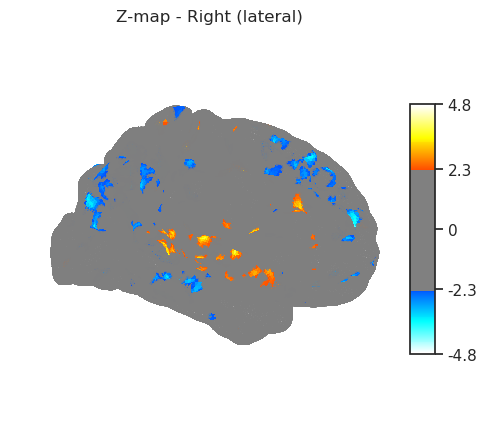

In [31]:
plot_z_map_surface(z_maps_live[1], threshold=2.3)

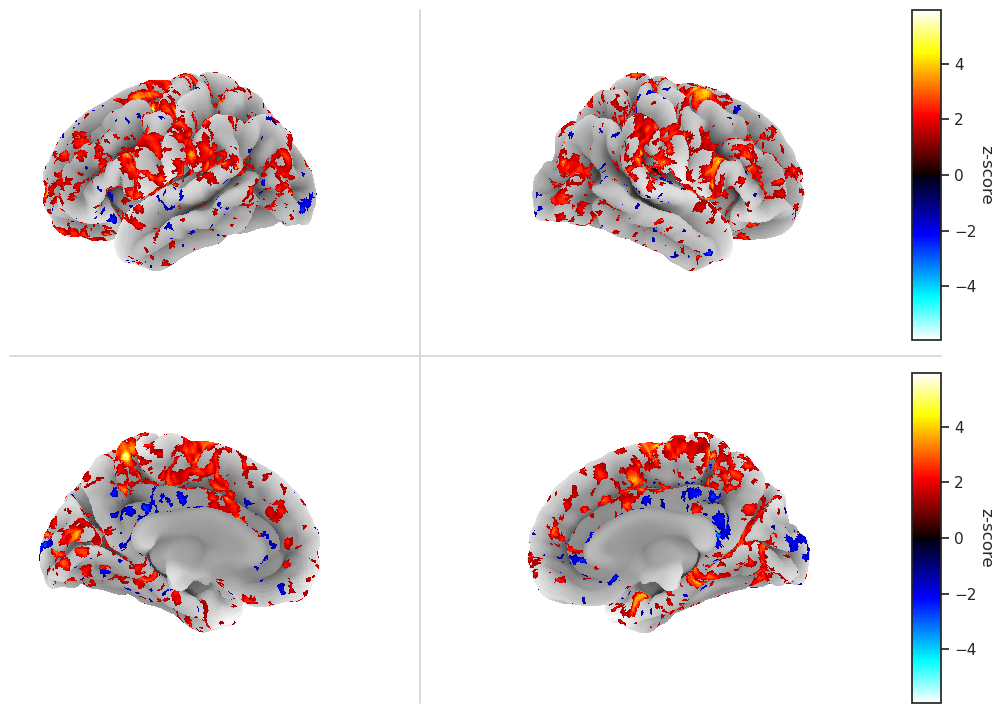

In [27]:
plot_z_map_surface_all_views(z_maps_pni[0])

In [ ]:
def run_second_level_gifti(z_maps_group1, z_maps_group2, 
                            label_group1='live', label_group2='pni',
                            alpha=0.05):
    """
    Run a second-level two-sample t-test on surface z-maps.
    
    Parameters
    ----------
    z_maps_group1 : list of SurfaceImage
        First-level z-maps for group 1 (one per subject)
    z_maps_group2 : list of SurfaceImage
        First-level z-maps for group 2 (one per subject)
    
    Returns
    -------
    dict with z-maps for: group1 > group2, group2 > group1, 
    and each group's one-sample effect
    """
    
    # Combine z-maps and build design matrix
    all_z_maps = z_maps_group1 + z_maps_group2
    n1, n2 = len(z_maps_group1), len(z_maps_group2)
    
    design_matrix = pd.DataFrame({
        label_group1: [1] * n1 + [0] * n2,
        label_group2: [0] * n1 + [1] * n2,
    })
    
    print(f"Design matrix ({n1 + n2} subjects):")
    print(design_matrix.value_counts())
    
    # Fit second level model
    second_level_model = SecondLevelModel(n_jobs=-1)
    second_level_model.fit(all_z_maps, design_matrix=design_matrix)
    
    # Contrasts
    contrasts = {
        f'{label_group1}_gt_{label_group2}': f'{label_group1} - {label_group2}',
        f'{label_group2}_gt_{label_group1}': f'{label_group2} - {label_group1}',
        f'{label_group1}_one_sample':         label_group1,
        f'{label_group2}_one_sample':         label_group2,
    }
    
    results = {}
    results_thresholded = {}
    for name, contrast_def in contrasts.items():
        results[name] = second_level_model.compute_contrast(
            contrast_def,
            output_type='z_score'
        )
        print(f"Computed: {name}")
        # Apply FDR correction
        thresholded_map, threshold = threshold_stats_img(
            results[name],
            alpha=alpha,
            height_control='fdr'   # swap to 'fpr' for uncorrected, 'bonferroni' for FWE
        )
        results_thresholded[name] = thresholded_map
        print(f"{name}: FDR threshold = {threshold:.3f}")
    
    return results, results_thresholded

In [ ]:
second_level_results, second_level_results_thresholded = run_second_level_gifti(z_maps_live, z_maps_pni)

In [ ]:
interactive_view_surf(second_level_results["live_gt_pni"])

In [ ]:
interactive_surface_plot(second_level_results["live_gt_pni"])

In [ ]:
plot_z_map_surface_all_views(second_level_results["live_gt_pni"], threshold=1.3, title="uncorrected")

In [ ]:
view = plotting.view_surf(
    surf_mesh=fsaverage6_mesh.parts['right'],  # or 'right'
    surf_map=second_level_results_thresholded["live_gt_pni"].data.parts['right'],        # extract the hemisphere's data
    threshold=1e-6,
    title=""
)
view

In [ ]:
plot_z_map_surface(second_level_results_thresholded["live_gt_pni"], threshold=1e-6)

In [ ]:
from nilearn.glm.second_level import non_parametric_inference

def run_second_level_nonparametric(z_maps_group1, z_maps_group2,
                                    label_group1='group1', label_group2='group2',
                                    n_perm=10000, n_jobs=-1, random_state=42):
    """
    Non-parametric second-level inference for a two-group comparison
    using permutation testing (label shuffling).

    Returns a dict of statistical maps:
        't'            - observed t-statistic map
        'logp_max_t'   - FWER-corrected -log10(p) via max-t distribution
        'logp_max_size'- FWER-corrected -log10(p) via cluster size
        'logp_max_mass'- FWER-corrected -log10(p) via cluster mass
    """
    all_z_maps = z_maps_group1 + z_maps_group2
    n1, n2 = len(z_maps_group1), len(z_maps_group2)

    design_matrix = pd.DataFrame({
        'intercept':        [1] * (n1 + n2),         # required by NiLearn
        label_group1:       [1] * n1 + [0] * n2,
    })
    # contrast: group1 > group2
    # (drop group2 column — intercept + one dummy is enough for 2 groups)

    print(f"Running {n_perm} permutations across {n1 + n2} subjects "
          f"({n1} {label_group1}, {n2} {label_group2})...")

    output = non_parametric_inference(
        second_level_input=all_z_maps,
        design_matrix=design_matrix,
        second_level_contrast=label_group1,   # tests group1 > intercept
        n_perm=n_perm,
        two_sided_test=True,                  # tests both directions
        random_state=random_state,
        n_jobs=n_jobs,
        verbose=1
    )

    return output

In [ ]:
second_level_nonparametric = run_second_level_nonparametric(z_maps_live, z_maps_pni)

In [ ]:
view = plotting.view_surf(
    surf_mesh=fsaverage6_mesh,  # or 'right'
    surf_map=second_level_nonparametric,        # extract the hemisphere's data
    threshold=1.3,
    title=""
)
view

In [ ]:
def plot_nonparametric_results(results_np, title_prefix="", threshold=1.3):
    """
    Plot non-parametric inference output maps.
    results_np: dict returned by non_parametric_inference
    threshold: in -log10(p) units. 1.3 = p<0.05, 2.0 = p<0.01, 3.0 = p<0.001
    """
    maps_to_plot = {
        'max-t FWER':        results_np['logp_max_t'],
        'cluster size FWER': results_np['logp_max_size'],
        'cluster mass FWER': results_np['logp_max_mass'],
        'raw t-statistic':   results_np['t'],           # unthresholded, for reference
    }

    # for map_name, stat_map in maps_to_plot.items():
    #     # raw t-map uses a z-score-like threshold, not -log10(p)
    #     thresh = 2.0 if map_name == 'raw t-statistic' else threshold

    for hemi in ['left', 'right']:
        for view in ['lateral', 'medial']:
            plotting.plot_surf_stat_map(
                surf_mesh=fsaverage6_mesh,
                stat_map=stat_map,
                hemi=hemi,
                view=view,
                threshold=thresh,
                colorbar=True,
                cmap='cold_hot',
                # title=f"{title_prefix} | {map_name} | {hemi} {view}"
            )
    plotting.show()

In [ ]:
second_level_nonparametric_output = run_second_level_nonparametric(z_maps_live, z_maps_pni)

In [ ]:
# plot_nonparametric_results(
#     second_level_nonparametric_output,
#     title_prefix="Patients > Controls",
#     threshold=1.3  # p < 0.05 FWER-corrected
# )

In [ ]:
interactive_view_surf(second_level_nonparametric_output)

In [ ]:
DESTRIEUX_NAMES = {
    'G_and_S_frontomargin':            'Fronto-marginal gyrus and sulcus',
    'G_and_S_occipital_inf':           'Inferior occipital gyrus and sulcus',
    'G_and_S_paracentral':             'Paracentral lobule and sulcus',
    'G_and_S_subcentral':              'Subcentral gyrus and sulci',
    'G_and_S_transv_frontopol':        'Transverse frontopolar gyri and sulci',
    'G_and_S_cingul-Ant':              'Anterior cingulate gyrus and sulcus',
    'G_and_S_cingul-Mid-Ant':          'Middle-anterior cingulate gyrus and sulcus',
    'G_and_S_cingul-Mid-Post':         'Middle-posterior cingulate gyrus and sulcus',
    'G_cingul-Post-dorsal':            'Posterior-dorsal cingulate gyrus',
    'G_cingul-Post-ventral':           'Posterior-ventral cingulate gyrus',
    'G_cuneus':                        'Cuneus',
    'G_front_inf-Opercular':           'Inferior frontal gyrus, opercular part',
    'G_front_inf-Orbital':             'Inferior frontal gyrus, orbital part',
    'G_front_inf-Triangul':            'Inferior frontal gyrus, triangular part',
    'G_front_middle':                  'Middle frontal gyrus',
    'G_front_sup':                     'Superior frontal gyrus',
    'G_Ins_lg_and_S_cent_ins':         'Long insular gyrus and central insular sulcus',
    'G_insular_short':                 'Short insular gyri',
    'G_occipital_middle':              'Middle occipital gyrus',
    'G_occipital_sup':                 'Superior occipital gyrus',
    'G_oc-temp_lat-fusifor':           'Lateral occipito-temporal gyrus (fusiform)',
    'G_oc-temp_med-Lingual':           'Lingual gyrus',
    'G_oc-temp_med-Parahip':           'Parahippocampal gyrus',
    'G_orbital':                       'Orbital gyri',
    'G_pariet_inf-Angular':            'Angular gyrus',
    'G_pariet_inf-Supramar':           'Supramarginal gyrus',
    'G_parietal_sup':                  'Superior parietal lobule',
    'G_postcentral':                   'Postcentral gyrus',
    'G_precentral':                    'Precentral gyrus',
    'G_precuneus':                     'Precuneus',
    'G_rectus':                        'Gyrus rectus',
    'G_subcallosal':                   'Subcallosal area',
    'G_temp_sup-G_T_transv':           "Transverse temporal gyrus (Heschl's gyrus)",
    'G_temp_sup-Lateral':              'Superior temporal gyrus, lateral aspect',
    'G_temp_sup-Plan_polar':           'Superior temporal gyrus, planum polare',
    'G_temp_sup-Plan_tempo':           'Superior temporal gyrus, planum temporale',
    'G_temporal_inf':                  'Inferior temporal gyrus',
    'G_temporal_middle':               'Middle temporal gyrus',
    'Lat_Fis-ant-Horizont':            'Lateral fissure, anterior horizontal ramus',
    'Lat_Fis-ant-Vertical':            'Lateral fissure, anterior vertical ramus',
    'Lat_Fis-post':                    'Lateral fissure, posterior ramus',
    'Pole_occipital':                  'Occipital pole',
    'Pole_temporal':                   'Temporal pole',
    'S_calcarine':                     'Calcarine sulcus',
    'S_central':                       'Central sulcus',
    'S_cingul-Marginalis':             'Marginal branch of cingulate sulcus',
    'S_circular_insula_ant':           'Anterior circular sulcus of insula',
    'S_circular_insula_inf':           'Inferior circular sulcus of insula',
    'S_circular_insula_sup':           'Superior circular sulcus of insula',
    'S_collat_transv_ant':             'Anterior transverse collateral sulcus',
    'S_collat_transv_post':            'Posterior transverse collateral sulcus',
    'S_front_inf':                     'Inferior frontal sulcus',
    'S_front_middle':                  'Middle frontal sulcus',
    'S_front_sup':                     'Superior frontal sulcus',
    'S_interm_prim-Jensen':            'Sulcus intermedius primus (Jensen)',
    'S_intrapariet_and_P_trans':       'Intraparietal sulcus and transverse parietal sulci',
    'S_oc_middle_and_Lunatus':         'Middle occipital sulcus and lunatus sulcus',
    'S_oc_sup_and_transversal':        'Superior occipital sulcus and transverse occipital sulcus',
    'S_occipital_ant':                 'Anterior occipital sulcus',
    'S_oc-temp_lat':                   'Lateral occipito-temporal sulcus',
    'S_oc-temp_med_and_Lingual':       'Medial occipito-temporal sulcus and lingual sulcus',
    'S_orbital_lateral':               'Lateral orbital sulcus',
    'S_orbital_med-olfact':            'Medial orbital sulcus (olfactory sulcus)',
    'S_orbital-H_Shaped':              'H-shaped orbital sulci',
    'S_parieto_occipital':             'Parieto-occipital sulcus',
    'S_pericallosal':                  'Pericallosal sulcus',
    'S_postcentral':                   'Postcentral sulcus',
    'S_precentral-inf-part':           'Precentral sulcus, inferior part',
    'S_precentral-sup-part':           'Precentral sulcus, superior part',
    'S_suborbital':                    'Suborbital sulcus',
    'S_subparietal':                   'Subparietal sulcus',
    'S_temporal_inf':                  'Inferior temporal sulcus',
    'S_temporal_sup':                  'Superior temporal sulcus',
    'S_temporal_transverse':           'Transverse temporal sulcus',
}

In [ ]:
from nilearn import datasets
from sklearn.neighbors import KDTree
import nibabel as nib
import numpy as np

fsaverage5 = datasets.fetch_surf_fsaverage(mesh='fsaverage5', data_dir=thesis_folder)
destrieux = datasets.fetch_atlas_surf_destrieux(data_dir=thesis_folder)  # fsaverage5 space

for hemi in ['left', 'right']:
    stat_data = second_level_nonparametric_output.data.parts[hemi]

    coords5, _ = nib.load(fsaverage5[f'sphere_{hemi}']).agg_data()
    coords6, _ = nib.load(fsaverage6[f'sphere_{hemi}']).agg_data()

    tree = KDTree(coords5)
    _, idx = tree.query(coords6, k=1)
    idx = idx.squeeze()

    parc_labels = destrieux[f'map_{hemi}'][idx]
    label_names = destrieux['labels']

    threshold = 1.3
    sig_verts = np.where(np.abs(stat_data) > threshold)[0]
    sig_parcel_ids = np.unique(parc_labels[sig_verts])

    rows = []
    for pid in sig_parcel_ids:
        if pid < 0:
            continue
        verts_in_parcel = np.intersect1d(sig_verts, np.where(parc_labels == pid)[0])
        short_name = label_names[pid].decode() if isinstance(label_names[pid], bytes) else str(label_names[pid])
        full_name = DESTRIEUX_NAMES.get(short_name, short_name)  # fallback to short if missing
        rows.append({
            'Parcel': full_name,
            'Number of vertices': len(verts_in_parcel),
            'Mean p': 10 ** (-stat_data[verts_in_parcel].mean()),
            'Max p':  10 ** (-stat_data[verts_in_parcel].max()),
        })

    df = (pd.DataFrame(rows)
            .sort_values('Number of vertices', ascending=False)
            .reset_index(drop=True))
    df.index += 1  # 1-based row numbering
    df.style.set_table_styles([{
                    'selector': 'th',
                    'props': [('font-weight', 'bold')]
                }]).hide(axis='index')

    df['Mean p'] = df['Mean p'].round(5)
    df['Max p']  = df['Max p'].round(5)

    print(f"\n{'='*82}")
    print(f"  {hemi.upper()} HEMISPHERE")
    print(f"{'='*82}")
    print(df.to_string())

In [ ]:
destrieux.keys()